# Tomato leaf disease classification

Image classification with a custom CNN and transfer learning on the New Plant Diseases dataset (Kaggle). The model takes a leaf photo and predicts which disease it has, or if it is healthy.

In [1]:
import os
import glob
import json
import time
import shutil

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

## Loading the data

The data is the Kaggle "New Plant Diseases Dataset" (vipoooool): about 87K leaf images in 38 classes. It is already split 80/20 into `train` and `valid` folders with one folder per class, named like `Tomato___Late_blight` (crop, then disease). It was made by augmenting the original PlantVillage images offline.

The download cell needs your `kaggle.json` (Kaggle account settings, Create New Token).

In [5]:
from google.colab import files

In [6]:
files.upload()

{}

In [7]:
!mkdir -p ~/.kaggle

In [8]:
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [9]:
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [10]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p data --unzip

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:26<00:00, 111MB/s]



In [11]:
train_dir = [p for p in glob.glob('data/**/train', recursive=True) if os.path.isdir(p)][0]

In [12]:
valid_dir = [p for p in glob.glob('data/**/valid', recursive=True) if os.path.isdir(p)][0]

In [13]:
train_dir, valid_dir

('data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
 'data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid')

In [14]:
sorted(os.listdir(train_dir))

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

The whole dataset is heavy for Colab, so only the tomato classes are used. They are copied into a separate `tomato` folder so the Keras loader can read just those.

In [15]:
tomato_classes = sorted([c for c in os.listdir(train_dir) if c.startswith('Tomato')])

In [16]:
len(tomato_classes)

10

In [17]:
for split, src in [('train', train_dir), ('valid', valid_dir)]:
    for c in tomato_classes:
        shutil.copytree(os.path.join(src, c), os.path.join('tomato', split, c), dirs_exist_ok=True)

## Inspection and EDA

Images per class in train and valid.

In [18]:
counts = pd.DataFrame({s: [len(os.listdir(f'tomato/{s}/{c}')) for c in tomato_classes] for s in ['train', 'valid']}, index=tomato_classes)

In [19]:
counts

,train,valid
Tomato___Bacterial_spot,1702,425
Tomato___Early_blight,1920,480
Tomato___Late_blight,1851,463
Tomato___Leaf_Mold,1882,470
Tomato___Septoria_leaf_spot,1745,436
Tomato___Spider_mites Two-spotted_spider_mite,1741,435
Tomato___Target_Spot,1827,457
Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961,490
Tomato___Tomato_mosaic_virus,1790,448
Tomato___healthy,1926,481


In [20]:
counts.sum()

,0
train,18345
valid,4585


<Axes: >

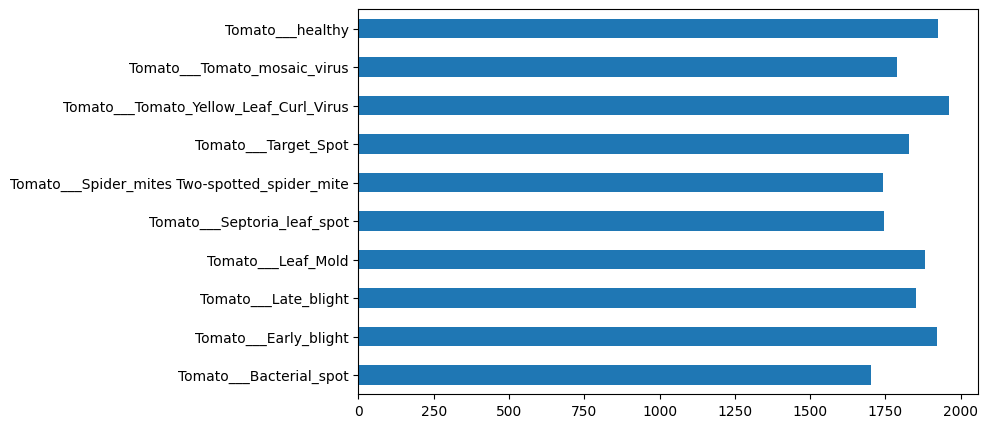

In [21]:
counts['train'].plot(kind='barh', figsize=(8, 5))

The ratio above is max class size over min class size. Close to 1 means the classes are balanced, so plain accuracy is a fair metric here.

In [22]:
counts['train'].max() / counts['train'].min()

1.1521739130434783

One image from every class. Some diseases look very similar (spots on the leaf), which is what makes this a real classification problem.

In [23]:
def first_image(c):
    return os.path.join('tomato/train', c, sorted(os.listdir(f'tomato/train/{c}'))[0])

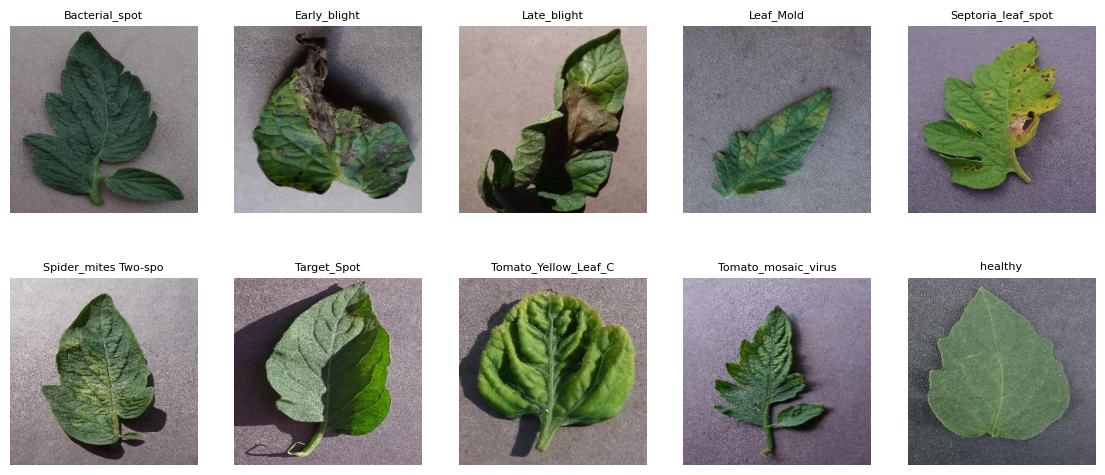

In [24]:
plt.figure(figsize=(14, 6))
for i, c in enumerate(tomato_classes):
    plt.subplot(2, 5, i + 1)
    plt.imshow(Image.open(first_image(c)))
    plt.title(c.replace('Tomato___', '')[:20], fontsize=8)
    plt.axis('off')

Checking the image size, all images should be the same size. They get resized to 128x128 later anyway.

In [25]:
Image.open(first_image(tomato_classes[0])).size

(256, 256)

In [26]:
pd.Series([Image.open(first_image(c)).size for c in tomato_classes]).value_counts()

,count
"(256, 256)",10


The dataset was augmented first and split afterwards, so a flipped or rotated copy of a leaf can end up in both train and valid. This check compares the ID part of the file names (the bit before `___`) between the two folders. A big overlap means validation and test accuracy will look better than they really are, worth mentioning in the report. It assumes the file names start with the leaf ID.

In [27]:
def leaf_ids(split):
    return {f.split('___')[0] for c in tomato_classes for f in os.listdir(f'tomato/{split}/{c}')}

In [28]:
overlap = leaf_ids('train') & leaf_ids('valid')

In [29]:
len(overlap), len(leaf_ids('valid'))

(1620, 4084)

## Cleaning

There are no missing values in an image dataset, so cleaning here means checking the files: extensions, and whether every image can actually be opened. Corrupted ones are deleted.

In [30]:
all_files = glob.glob('tomato/*/*/*')

In [31]:
len(all_files)

22930

In [32]:
pd.Series([os.path.splitext(p)[1].lower() for p in all_files]).value_counts()

,count
.jpg,22930


In [33]:
def is_bad(path):
    try:
        Image.open(path).verify()
        return False
    except Exception:
        return True

In [34]:
bad_files = [p for p in all_files if is_bad(p)]

In [35]:
len(bad_files)

0

In [36]:
for p in bad_files:
    os.remove(p)

## Loading as tensors

Images are read as 128x128 RGB arrays in batches of 32 (smaller than the original to keep training quick). The `valid` folder is split in half with a fixed seed, one half is used for validation during training and the other half is kept as the test set.

In [37]:
img_size = (128, 128)

In [38]:
batch_size = 32

In [39]:
keras.utils.set_random_seed(42)

In [40]:
train_ds = keras.utils.image_dataset_from_directory('tomato/train', image_size=img_size, batch_size=batch_size, seed=42)

Found 18345 files belonging to 10 classes.


In [41]:
val_ds = keras.utils.image_dataset_from_directory('tomato/valid', validation_split=0.5, subset='training', seed=42, image_size=img_size, batch_size=batch_size)

Found 4585 files belonging to 10 classes.
Using 2293 files for training.


In [42]:
test_ds = keras.utils.image_dataset_from_directory('tomato/valid', validation_split=0.5, subset='validation', seed=42, image_size=img_size, batch_size=batch_size)

Found 4585 files belonging to 10 classes.
Using 2292 files for validation.


In [43]:
class_names = train_ds.class_names

In [44]:
n_classes = len(class_names)

In [45]:
short_names = [c.replace('Tomato___', '') for c in class_names]

Pixel scaling is done inside the models so it is saved with them: divide by 255 for the custom CNN, and scale to -1..1 for MobileNetV2 since that is how it was trained.

In [46]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [47]:
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [48]:
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [49]:
images, labels = next(iter(train_ds))

In [50]:
images.shape, images.numpy().max()

(TensorShape([32, 128, 128, 3]), np.float32(255.0))

## Augmentation

Random flips, a small rotation, zoom and contrast. These are layers, so they only run while training and are off when predicting. Below is one leaf augmented 8 times.

In [51]:
augment = keras.Sequential([layers.RandomFlip('horizontal_and_vertical'), layers.RandomRotation(0.1), layers.RandomZoom(0.1), layers.RandomContrast(0.1)])

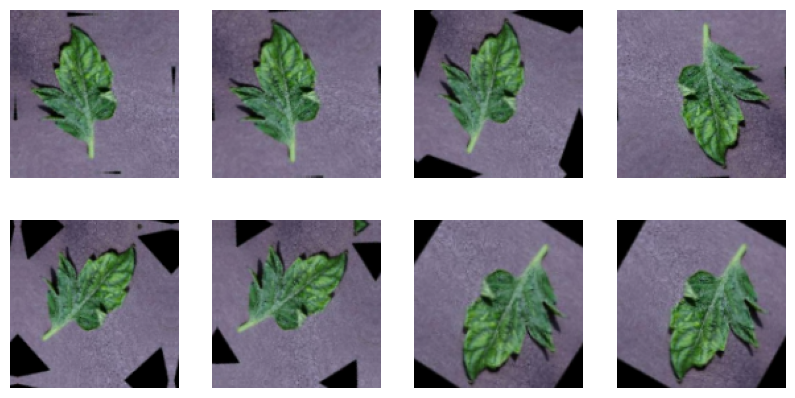

In [52]:
plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    out = augment(images[:1], training=True)[0].numpy()
    plt.imshow(np.clip(out, 0, 255).astype('uint8'))
    plt.axis('off')

## Models

Custom CNN: three conv + max pool blocks, global average pooling, a dense layer and dropout. Transfer learning: MobileNetV2 with ImageNet weights, frozen at first with a new classification head on top.

In [53]:
def build_cnn(use_aug):
    inputs = keras.Input(shape=img_size + (3,))
    x = augment(inputs) if use_aug else inputs
    x = layers.Rescaling(1. / 255)(x)
    for f in [32, 64, 128]:
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

In [54]:
def build_transfer():
    base = keras.applications.MobileNetV2(input_shape=img_size + (3,), include_top=False, weights='imagenet')
    base.trainable = False
    inputs = keras.Input(shape=img_size + (3,))
    x = augment(inputs)
    x = layers.Rescaling(1. / 127.5, offset=-1)(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs), base

Training uses Adam and early stopping on validation loss (patience 3). Every run saves its model to disk, because the fine-tuning step reuses the same model object and would otherwise overwrite the frozen one.

In [55]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [56]:
results = []

In [57]:
histories = {}

In [58]:
def run_experiment(name, model, epochs, lr):
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[early_stop], verbose=2)
    secs = time.time() - start
    val_acc = model.evaluate(val_ds, verbose=0)[1]
    test_acc = model.evaluate(test_ds, verbose=0)[1]
    model.save(f'{name}.keras')
    histories[name] = hist.history
    results.append({'Model': name, 'Params': model.count_params(), 'Val acc': val_acc, 'Test acc': test_acc, 'Time (s)': secs})

In [59]:
def plot_history(name):
    h = histories[name]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h['accuracy'], label='train')
    plt.plot(h['val_accuracy'], label='val')
    plt.title(name + ' accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h['loss'], label='train')
    plt.plot(h['val_loss'], label='val')
    plt.title(name + ' loss')
    plt.legend()

## Experiments

Four runs: custom CNN without augmentation, custom CNN with augmentation, MobileNetV2 frozen, and MobileNetV2 fine-tuned (last 30 layers unfrozen, learning rate 1e-5).

In [60]:
cnn_plain = build_cnn(False)

In [61]:
cnn_plain.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
run_experiment('cnn_no_aug', cnn_plain, 15, 1e-3)

Epoch 1/15
574/574 - 24s - 42ms/step - accuracy: 0.3708 - loss: 1.6922 - val_accuracy: 0.4444 - val_loss: 1.4679
Epoch 2/15
574/574 - 14s - 25ms/step - accuracy: 0.5848 - loss: 1.1515 - val_accuracy: 0.5246 - val_loss: 1.3702
Epoch 3/15
574/574 - 15s - 26ms/step - accuracy: 0.7012 - loss: 0.8318 - val_accuracy: 0.7662 - val_loss: 0.6568
Epoch 4/15
574/574 - 19s - 34ms/step - accuracy: 0.7723 - loss: 0.6458 - val_accuracy: 0.8216 - val_loss: 0.4848
Epoch 5/15
574/574 - 14s - 24ms/step - accuracy: 0.8116 - loss: 0.5450 - val_accuracy: 0.8644 - val_loss: 0.3989
Epoch 6/15
574/574 - 14s - 24ms/step - accuracy: 0.8389 - loss: 0.4702 - val_accuracy: 0.8753 - val_loss: 0.3667
Epoch 7/15
574/574 - 15s - 27ms/step - accuracy: 0.8505 - loss: 0.4321 - val_accuracy: 0.8670 - val_loss: 0.3890
Epoch 8/15
574/574 - 14s - 25ms/step - accuracy: 0.8668 - loss: 0.3874 - val_accuracy: 0.8801 - val_loss: 0.3484
Epoch 9/15
574/574 - 22s - 38ms/step - accuracy: 0.8774 - loss: 0.3597 - val_accuracy: 0.9014 - 

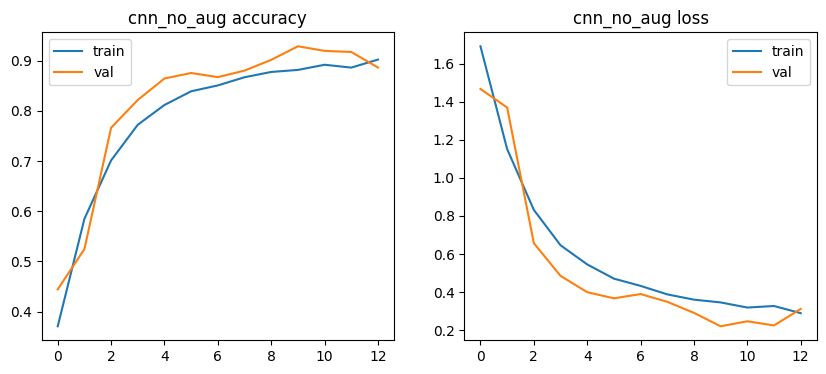

In [63]:
plot_history('cnn_no_aug')

In [64]:
cnn_aug = build_cnn(True)

In [65]:
run_experiment('cnn_aug', cnn_aug, 15, 1e-3)

Epoch 1/15
574/574 - 22s - 39ms/step - accuracy: 0.3242 - loss: 1.7861 - val_accuracy: 0.4775 - val_loss: 1.3555
Epoch 2/15
574/574 - 20s - 36ms/step - accuracy: 0.5332 - loss: 1.2659 - val_accuracy: 0.5364 - val_loss: 1.2992
Epoch 3/15
574/574 - 16s - 28ms/step - accuracy: 0.6739 - loss: 0.9304 - val_accuracy: 0.6812 - val_loss: 0.8618


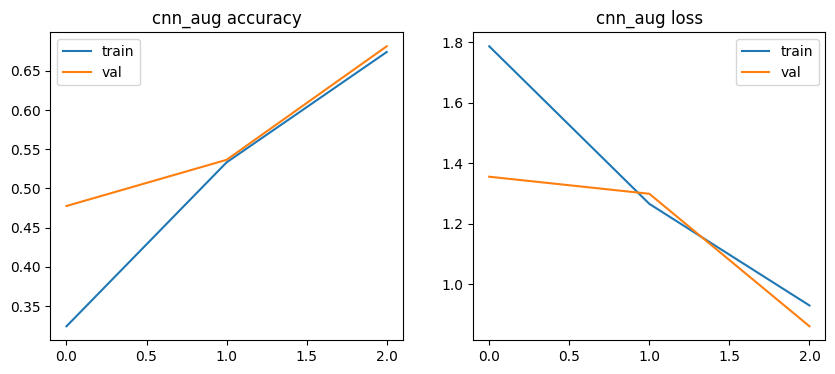

In [66]:
plot_history('cnn_aug')

In [67]:
tl_model, base = build_transfer()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [68]:
tl_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [69]:
run_experiment('mobilenet_frozen', tl_model, 8, 1e-3)

Epoch 1/8
574/574 - 29s - 50ms/step - accuracy: 0.6605 - loss: 0.9879 - val_accuracy: 0.7693 - val_loss: 0.7036
Epoch 2/8
574/574 - 19s - 33ms/step - accuracy: 0.7842 - loss: 0.6270 - val_accuracy: 0.8016 - val_loss: 0.6128
Epoch 3/8
574/574 - 20s - 35ms/step - accuracy: 0.8063 - loss: 0.5677 - val_accuracy: 0.8251 - val_loss: 0.5294


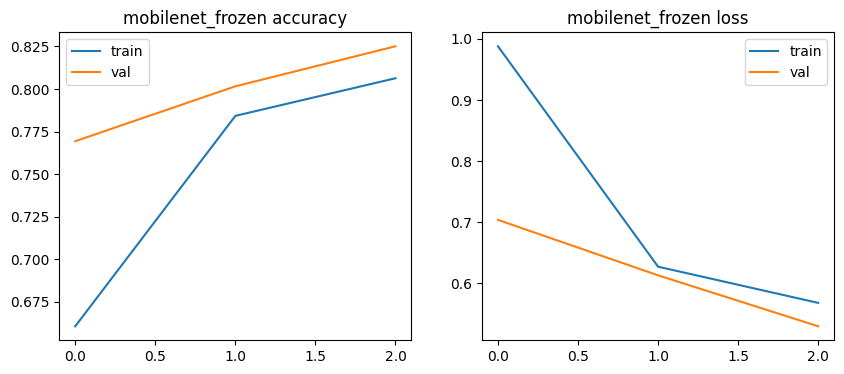

In [70]:
plot_history('mobilenet_frozen')

In [71]:
base.trainable = True

In [72]:
for layer in base.layers[:-30]:
    layer.trainable = False

In [73]:
run_experiment('mobilenet_finetuned', tl_model, 6, 1e-5)

Epoch 1/6
574/574 - 39s - 69ms/step - accuracy: 0.6405 - loss: 1.1968 - val_accuracy: 0.7427 - val_loss: 0.7693
Epoch 2/6
574/574 - 28s - 50ms/step - accuracy: 0.7931 - loss: 0.6089 - val_accuracy: 0.8094 - val_loss: 0.5655
Epoch 3/6
574/574 - 29s - 50ms/step - accuracy: 0.8315 - loss: 0.4924 - val_accuracy: 0.8517 - val_loss: 0.4553


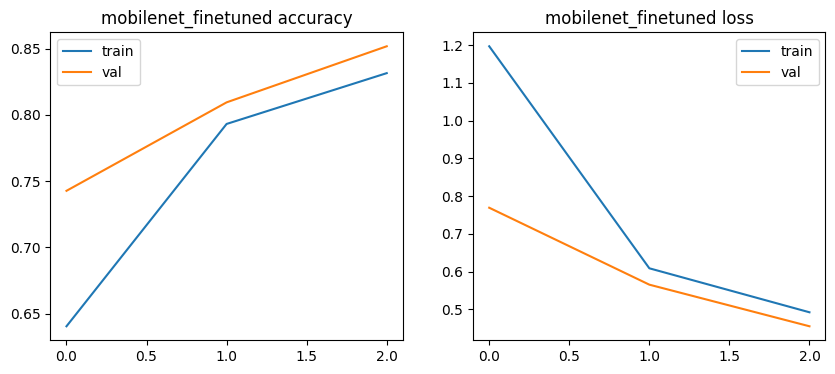

In [74]:
plot_history('mobilenet_finetuned')

## Comparison

All four runs side by side. The best model is picked using validation accuracy, not test accuracy, so the test set is only used for reporting. The time chart shows what each approach costs.

In [75]:
results_df = pd.DataFrame(results)

In [76]:
results_df.sort_values('Val acc', ascending=False)

,Model,Params,Val acc,Test acc,Time (s)
0,cnn_no_aug,111050,0.928478,0.932810,219.132024
2,mobilenet_frozen,2270794,0.769298,0.771379,68.321077
3,mobilenet_finetuned,2270794,0.742695,0.752182,96.533153
1,cnn_aug,111050,0.477540,0.506108,58.993354


<Axes: xlabel='Model'>

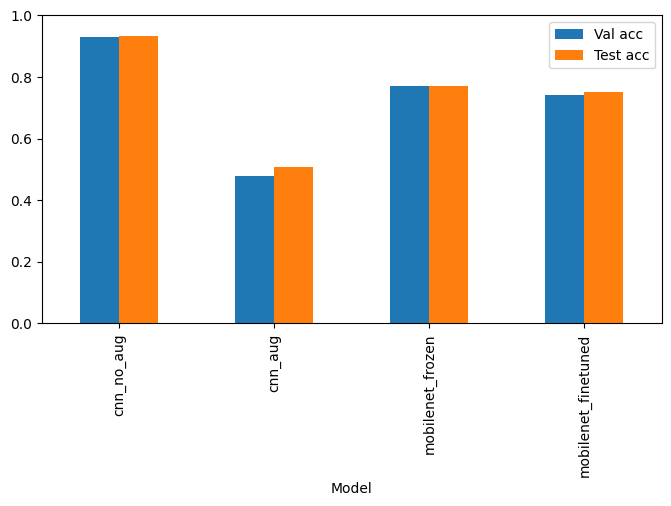

In [77]:
results_df.set_index('Model')[['Val acc', 'Test acc']].plot(kind='bar', figsize=(8, 4), ylim=(0, 1))

<Axes: xlabel='Model'>

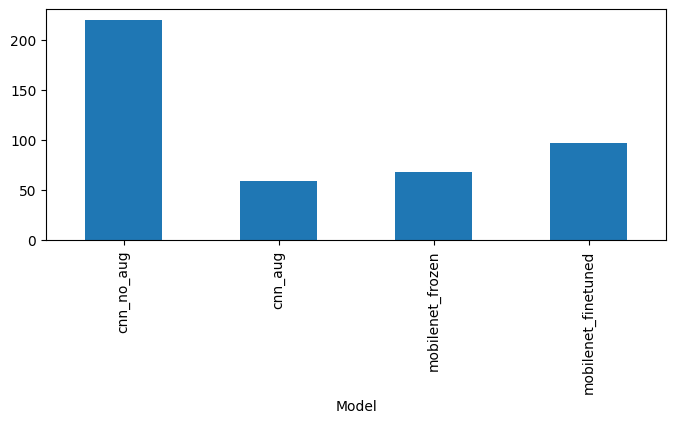

In [78]:
results_df.set_index('Model')['Time (s)'].plot(kind='bar', figsize=(8, 3))

In [79]:
best_name = results_df.sort_values('Val acc', ascending=False).iloc[0]['Model']

In [80]:
best_name

'cnn_no_aug'

In [81]:
best_model = keras.models.load_model(f'{best_name}.keras')

## Final evaluation

Classification report and confusion matrix for the best model on the test half.

In [82]:
def get_preds(model, ds):
    y_true, y_pred = [], []
    for x, y in ds:
        y_true.extend(y.numpy())
        y_pred.extend(model.predict(x, verbose=0).argmax(axis=1))
    return np.array(y_true), np.array(y_pred)

In [83]:
y_true, y_pred = get_preds(best_model, test_ds)

In [84]:
print(classification_report(y_true, y_pred, target_names=short_names))

                                      precision    recall  f1-score   support

                      Bacterial_spot       0.92      0.92      0.92       207
                        Early_blight       0.86      0.94      0.90       245
                         Late_blight       0.96      0.83      0.89       238
                           Leaf_Mold       0.95      0.99      0.97       227
                  Septoria_leaf_spot       0.92      0.94      0.93       220
Spider_mites Two-spotted_spider_mite       0.92      0.86      0.89       189
                         Target_Spot       0.92      0.89      0.90       245
       Tomato_Yellow_Leaf_Curl_Virus       0.97      0.96      0.96       269
                 Tomato_mosaic_virus       0.96      1.00      0.98       217
                             healthy       0.96      1.00      0.97       235

                            accuracy                           0.93      2292
                           macro avg       0.93      0.93     

<Axes: >

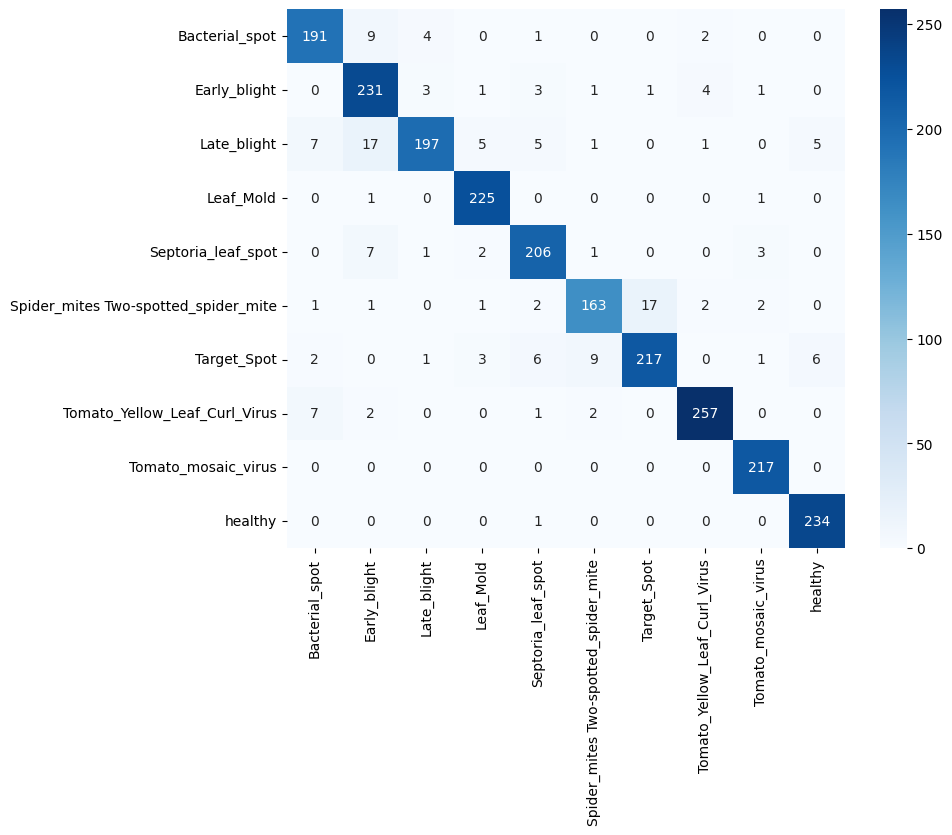

In [85]:
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=short_names, yticklabels=short_names)

A few test images with the predicted class and the actual class in brackets.

In [86]:
imgs, labs = next(iter(test_ds))
preds = best_model.predict(imgs, verbose=0).argmax(axis=1)

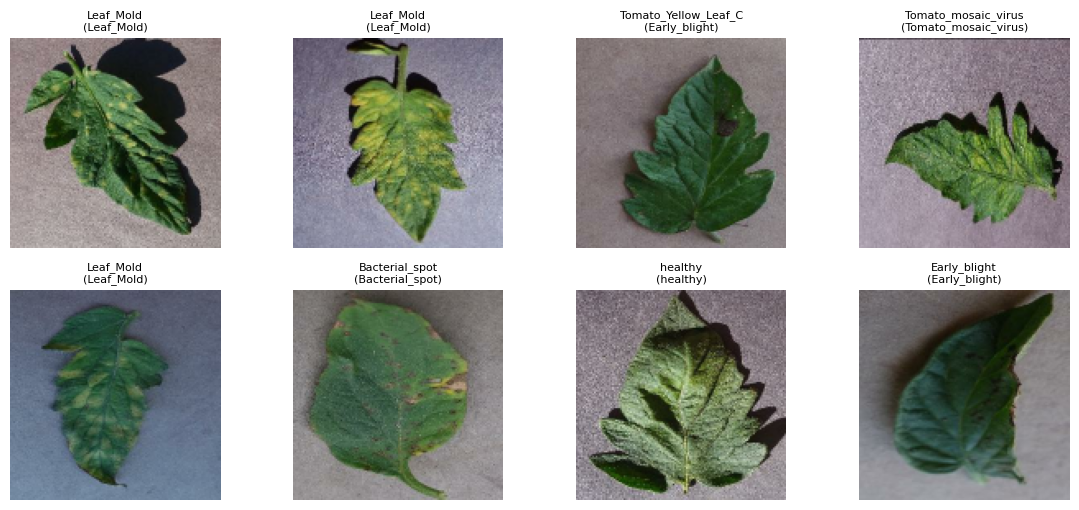

In [87]:
plt.figure(figsize=(14, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imgs[i].numpy().astype('uint8'))
    plt.title(f'{short_names[preds[i]][:20]}\n({short_names[labs[i]][:20]})', fontsize=8)
    plt.axis('off')

## Saving

The model is saved as a `.keras` file (the scaling and augmentation layers are inside it) along with the class names. Both files are needed by the app.

In [88]:
best_model.save('plant_disease_model.keras')

In [89]:
json.dump(class_names, open('class_names.json', 'w'))

In [90]:
files.download('plant_disease_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
files.download('class_names.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Prototype

This function does what the app does: load an image, resize, predict, return the top 3 classes. The GUI is `app.py`, run locally on your own machine, not in Colab.

In [92]:
def predict_image(path, model):
    img = np.array(Image.open(path).convert('RGB'))
    arr = tf.image.resize(img, img_size).numpy()[None]
    probs = model.predict(arr, verbose=0)[0]
    top = probs.argsort()[::-1][:3]
    return [(short_names[i], round(float(probs[i]) * 100, 1)) for i in top]

In [93]:
sample = first_image(tomato_classes[2]).replace('train', 'valid')

In [94]:
sample

'tomato/valid/Tomato___Late_blight/0003faa8-4b27-4c65-bf42-6d9e352ca1a5___RS_Late.B 4946.JPG'